In [2]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [5]:
## Step 1: Load Dataset
df = pd.read_csv(r"C:\Users\ayush kumar gupta\OneDrive\Desktop\Twitter_Data.csv")

df.head(15)

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
5,kiya tho refresh maarkefir comment karo,0.0
6,surat women perform yagna seeks divine grace f...,0.0
7,this comes from cabinet which has scholars lik...,0.0
8,with upcoming election india saga going import...,1.0
9,gandhi was gay does modi,1.0


In [24]:
##step 2
#Checking rows, columns and missing values.

In [7]:

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Shape of Dataset:
(162980, 2)

Column Names:
Index(['clean_text', 'category'], dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [9]:
df.isnull().sum()

clean_text    4
category      7
dtype: int64

In [11]:
## Step 3: Data Cleaning

In [12]:
## Step 3: Handling Missing Values

#First, the missing values were checked.

#Since the number of missing records was very small compared to the total dataset size, those records were removed.

In [13]:
df.dropna(inplace=True)

print(df.shape)

(162969, 2)


In [14]:
## Step 4: Converting Labels

#Converting numerical sentiment values into readable labels.

In [15]:
df["category"] = df["category"].replace({
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
})

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,Negative
1,talk all the nonsense and continue all the dra...,Neutral
2,what did just say vote for modi welcome bjp t...,Positive
3,asking his supporters prefix chowkidar their n...,Positive
4,answer who among these the most powerful world...,Positive


In [16]:
## Step 5: Sentiment Distribution

#Visualizing sentiment categories.

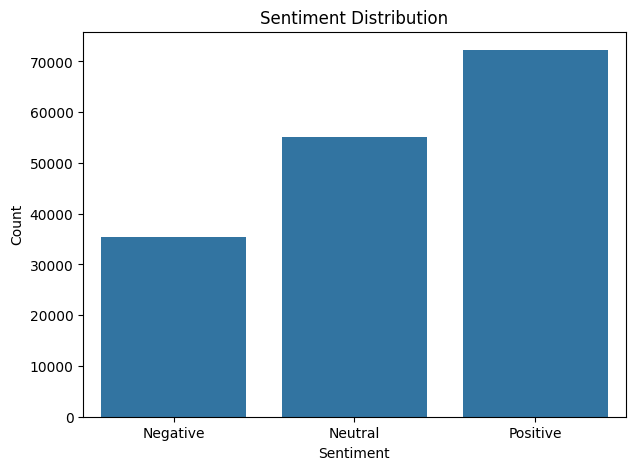

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="category",
    data=df
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [18]:
## Step 6: Text Preprocessing

#Cleaning text data using NLP techniques.

In [19]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"\d+","",text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = text.strip()

    return text

In [20]:
df["cleaned_text"] = df["clean_text"].apply(clean_text)

df[["clean_text","cleaned_text"]].head()

,clean_text,cleaned_text
0,when modi promised “minimum government maximum...,when modi promised “minimum government maximum...
1,talk all the nonsense and continue all the dra...,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,what did just say vote for modi welcome bjp t...
3,asking his supporters prefix chowkidar their n...,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,answer who among these the most powerful world...


In [21]:
## Step 7: Feature Engineering Using TF-IDF

#Converting text data into numerical features.

In [22]:
X = df["cleaned_text"]

y = df["category"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(X)

In [23]:
## Step 8: Splitting Dataset

# 80% Training Data and 20% Testing Data.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
## Step 9: Naive Bayes Model

In [27]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.7044241271399644


In [28]:
## Step 10: Logistic Regression Model

In [29]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8562005277044855


In [30]:
## Step 11: Support Vector Machine (SVM)

In [31]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.8618457384794748


In [32]:
## Step 12: Model Comparison

In [33]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        nb_acc,
        lr_acc,
        svm_acc
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.704424
1,Logistic Regression,0.856201
2,SVM,0.861846


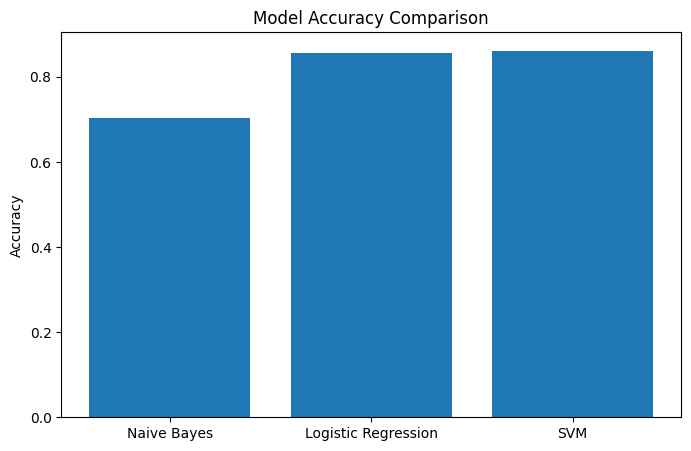

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [35]:
## Step 13: Classification Report

In [36]:
print(classification_report(
    y_test,
    svm_pred
))

              precision    recall  f1-score   support

    Negative       0.85      0.78      0.81      7152
     Neutral       0.82      0.96      0.88     11067
    Positive       0.91      0.83      0.87     14375

    accuracy                           0.86     32594
   macro avg       0.86      0.86      0.85     32594
weighted avg       0.87      0.86      0.86     32594



In [37]:
## Step 14: Confusion Matrix

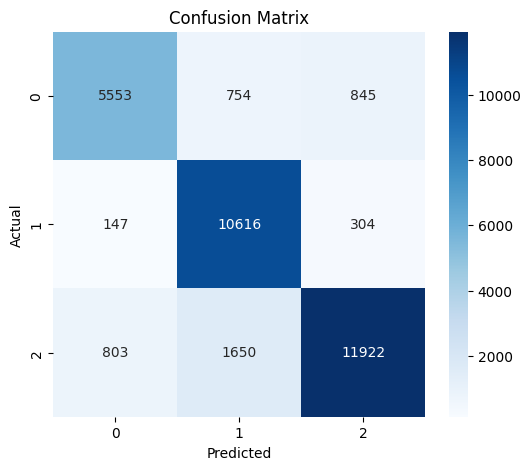

In [38]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
## Step 15: Sentiment Percentage

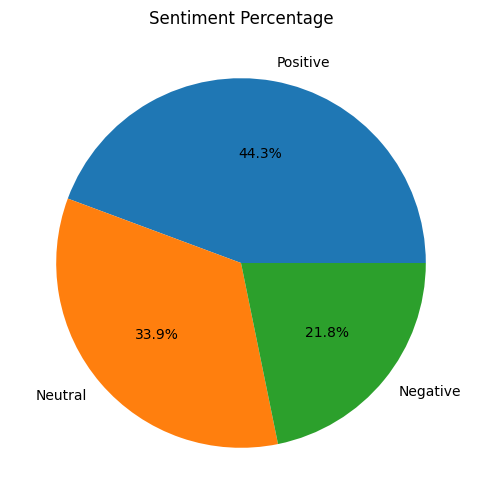

In [40]:
sentiment_counts = df["category"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Sentiment Percentage")

plt.show()

In [41]:
## Step 16: Tweet Length Analysis

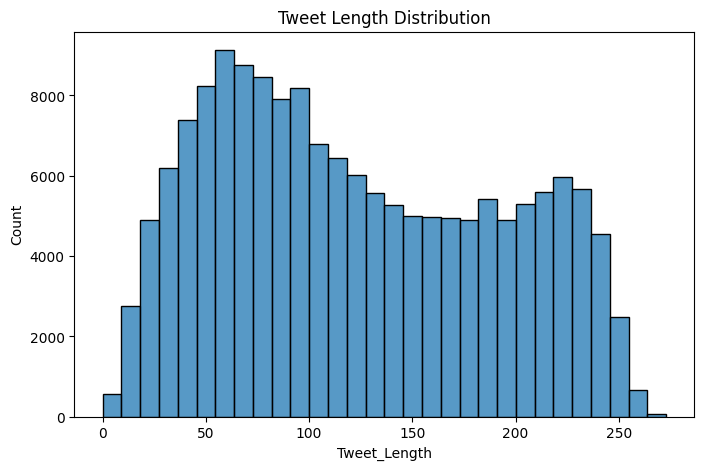

In [42]:
df["Tweet_Length"] = df["cleaned_text"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df["Tweet_Length"],
    bins=30
)

plt.title("Tweet Length Distribution")

plt.show()

In [43]:
## Step 17: Custom Prediction

In [44]:
sample = [
    "This product is amazing and I really love it"
]

sample_vector = vectorizer.transform(sample)

prediction = svm_model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


In [ ]:
## Key Concepts Implemented

### 1. Sentiment Analysis
Tweets were classified into Positive, Negative and Neutral categories.

### 2. Natural Language Processing (NLP)
Text cleaning and preprocessing techniques were applied to prepare the data.

### 3. Machine Learning Algorithms
Naive Bayes, Logistic Regression and Support Vector Machine (SVM) models were implemented and compared.

### 4. Feature Engineering
TF-IDF was used to convert text into numerical features.

### 5. Data Visualization
Various visualizations were created including sentiment distribution, model comparison, confusion matrix, pie chart and tweet length analysis.

In [45]:
df.to_csv("cleaned_twitter_data.csv", index=False)